# first part

In [ ]:
import numpy as np

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    return x * (1 - x)


#np.random.seed(42)
weights_input_hidden = np.random.uniform(-5, 5, (2, 2))
weights_hidden_output = np.random.uniform(-5, 5, (2, 1))
bias_hidden = np.random.uniform(-5, 5, (1, 2))
bias_output = np.random.uniform(-5, 5, (1, 1))

X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y = np.array([[0], [1], [1], [0]])

epochs = 10000
learning_rate = 0.1

for epoch in range(epochs):
    hidden_layer_input = np.dot(X, weights_input_hidden) + bias_hidden
    hidden_layer_output = sigmoid(hidden_layer_input)

    output_layer_input = np.dot(hidden_layer_output, weights_hidden_output) + bias_output
    output_layer_output = sigmoid(output_layer_input)

    error = y - output_layer_output

    d_output = error * sigmoid_derivative(output_layer_output)
    error_hidden_layer = d_output.dot(weights_hidden_output.T)
    d_hidden_layer = error_hidden_layer * sigmoid_derivative(hidden_layer_output)

    weights_hidden_output += hidden_layer_output.T.dot(d_output) * learning_rate
    bias_output += np.sum(d_output, axis=0, keepdims=True) * learning_rate
    weights_input_hidden += X.T.dot(d_hidden_layer) * learning_rate
    bias_hidden += np.sum(d_hidden_layer, axis=0, keepdims=True) * learning_rate

print("Final Output after Training:")
print(output_layer_output)


Final Output after Training:
[[0.04440892]
 [0.94674274]
 [0.94647247]
 [0.05334765]]


In [ ]:
import numpy as np

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y = np.array([[0], [1], [1], [0]])

def fitness(weights):

    w_ih = weights[:4].reshape(2, 2)
    w_ho = weights[4:6].reshape(2, 1)
    b_h = weights[6:8].reshape(1, 2)
    b_o = weights[8:9].reshape(1, 1)

    hidden_layer_input = np.dot(X, w_ih) + b_h
    hidden_layer_output = sigmoid(hidden_layer_input)
    output_layer_input = np.dot(hidden_layer_output, w_ho) + b_o
    output_layer_output = sigmoid(output_layer_input)

    error = y - output_layer_output
    mse = np.mean(error ** 2)
    return 1 / (mse + 1e-6)

population_size = 20
generations = 1000
mutation_rate = 0.1
chromosome_length = 9

np.random.seed(42)
population = np.random.uniform(-5, 5, (population_size, chromosome_length))

for generation in range(generations):
    fitness_scores = np.array([fitness(individual) for individual in population])

    elite_idx = np.argsort(fitness_scores)[-2:]
    elite_individuals = population[elite_idx]

    probabilities = fitness_scores / fitness_scores.sum()

    new_population = []
    for _ in range(population_size // 2):
        parents_idx = np.random.choice(np.arange(population_size), size=2, p=probabilities)
        parent1, parent2 = population[parents_idx]

        crossover_point = np.random.randint(1, chromosome_length - 1)
        child1 = np.concatenate((parent1[:crossover_point], parent2[crossover_point:]))
        child2 = np.concatenate((parent2[:crossover_point], parent1[crossover_point:]))


        if np.random.rand() < mutation_rate:
            mutation_idx = np.random.randint(0, chromosome_length)
            child1[mutation_idx] += np.random.uniform(-1, 1)
        if np.random.rand() < mutation_rate:
            mutation_idx = np.random.randint(0, chromosome_length)
            child2[mutation_idx] += np.random.uniform(-1, 1)

        new_population.extend([child1, child2])

    population = np.array(new_population)
    population[:2] = elite_individuals

    best_fitness = fitness_scores[elite_idx[-1]]
    print(f"Generation {generation + 1}, Best Fitness: {best_fitness}")

best_individual = population[np.argmax(fitness_scores)]
print("Best weights found:", best_individual)


Generation 1, Best Fitness: 4.9196607655174684
Generation 2, Best Fitness: 4.9196607655174684
Generation 3, Best Fitness: 4.9196607655174684
Generation 4, Best Fitness: 4.9196607655174684
Generation 5, Best Fitness: 4.9196607655174684
Generation 6, Best Fitness: 5.277451248156725
Generation 7, Best Fitness: 5.277451248156725
Generation 8, Best Fitness: 5.277451248156725
Generation 9, Best Fitness: 5.277451248156725
Generation 10, Best Fitness: 5.353133629468932
Generation 11, Best Fitness: 5.400422899205757
Generation 12, Best Fitness: 5.417898562035357
Generation 13, Best Fitness: 5.417898562035357
Generation 14, Best Fitness: 5.417898562035357
Generation 15, Best Fitness: 5.417898562035357
Generation 16, Best Fitness: 5.417898562035357
Generation 17, Best Fitness: 5.558224995743117
Generation 18, Best Fitness: 5.558224995743117
Generation 19, Best Fitness: 5.558224995743117
Generation 20, Best Fitness: 5.558224995743117
Generation 21, Best Fitness: 5.733534109838219
Generation 22, Be

# Second part


In [ ]:
import scipy.io as sio

data_path = '/content/Data_hoda_full.mat'
data = sio.loadmat(data_path)
data.keys()


dict_keys(['__header__', '__version__', '__globals__', 'Data', 'labels'])

In [ ]:
data_images = data['Data']
data_labels = data['labels']

data_images.shape, data_labels.shape


((60000, 1), (60000, 1))

Original shape: (27, 20)


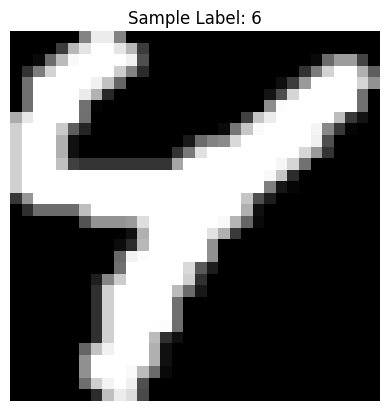

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.transform import resize

print(f"Original shape: {data_images[0][0].shape}")

resized_image = resize(data_images[0][0], (32, 32), mode='constant', anti_aliasing=True)

plt.imshow(resized_image, cmap='gray')
plt.title(f"Sample Label: {data_labels[0][0]}")
plt.axis('off')
plt.show()


In [ ]:
data_images[0]


array([array([[  0,   0,   0,   0, 255, 255,   0,   0,   0,   0,   0,   0,   0,
                 0,   0,   0,   0,   0,   0,   0],
              [  0,   0,   0, 255, 255, 255, 255,   0,   0,   0,   0,   0,   0,
                 0,   0,   0,   0,   0,   0,   0],
              [  0,   0, 255, 255, 255, 255, 255,   0,   0,   0,   0,   0,   0,
                 0,   0,   0,   0, 255, 255,   0],
              [  0, 255, 255, 255, 255, 255,   0,   0,   0,   0,   0,   0,   0,
                 0,   0,   0, 255, 255, 255, 255],
              [  0, 255, 255, 255, 255,   0,   0,   0,   0,   0,   0,   0,   0,
                 0,   0, 255, 255, 255, 255,   0],
              [  0, 255, 255, 255,   0,   0,   0,   0,   0,   0,   0,   0,   0,
                 0, 255, 255, 255, 255, 255,   0],
              [255, 255, 255, 255,   0,   0,   0,   0,   0,   0,   0,   0,   0,
               255, 255, 255, 255, 255,   0,   0],
              [255, 255, 255,   0,   0,   0,   0,   0,   0,   0,   0,   0, 255,
   

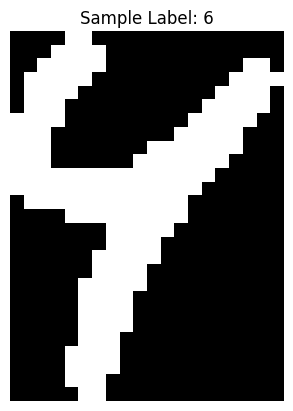

In [ ]:
sample_image = data_images[0][0]  # Accessing the nested array directly
sample_label = data_labels[0][0]
sample_image.shape

plt.imshow(sample_image, cmap='gray')
plt.title(f"Sample Label: {sample_label}")
plt.axis('off')
plt.show()


In [ ]:
from skimage.transform import resize
import numpy as np

fixed_size = (32, 32)
normalized_images = []

for img in data_images:
    resized_image = resize(img[0], fixed_size, mode='constant', anti_aliasing=True)  # Resize each image
    normalized_images.append(resized_image / 255.0)  # Normalize pixel values

normalized_images = np.array(normalized_images, dtype=np.float32)

train_size = 3000
test_size = 1000

train_images = normalized_images[:train_size]
train_labels = data_labels[:train_size].flatten()

test_images = normalized_images[train_size:train_size + test_size]
test_labels = data_labels[train_size:train_size + test_size].flatten()

print(train_images.shape, train_labels.shape, test_images.shape, test_labels.shape)


(3000, 32, 32) (3000,) (1000, 32, 32) (1000,)


In [ ]:
import numpy as np

def zoning_features(images, grid_size=(4, 4)):
    features = []
    grid_h, grid_w = grid_size
    for img in images:
        h, w = img.shape
        fh, fw = h // grid_h, w // grid_w  # Size of each zone
        zones = [
            np.mean(img[i * fh:(i + 1) * fh, j * fw:(j + 1) * fw])
            for i in range(grid_h)
            for j in range(grid_w)
        ]
        features.append(zones)
    return np.array(features)

def histogram_features(images):
    horizontal_histograms = [np.sum(img, axis=1) for img in images]
    vertical_histograms = [np.sum(img, axis=0) for img in images]
    return np.array(horizontal_histograms), np.array(vertical_histograms)

zoning_grid_size = (4, 4)
zoning_features_train = zoning_features(train_images, grid_size=zoning_grid_size)
zoning_features_test = zoning_features(test_images, grid_size=zoning_grid_size)

horizontal_histograms_train, vertical_histograms_train = histogram_features(train_images)
horizontal_histograms_test, vertical_histograms_test = histogram_features(test_images)

histogram_features_train = np.hstack([horizontal_histograms_train, vertical_histograms_train])
histogram_features_test = np.hstack([horizontal_histograms_test, vertical_histograms_test])

print("Zoning Features Shape (Train):", zoning_features_train.shape)
print("Histogram Features Shape (Train):", histogram_features_train.shape)
print("Zoning Features Shape (Test):", zoning_features_test.shape)
print("Histogram Features Shape (Test):", histogram_features_test.shape)


Zoning Features Shape (Train): (3000, 16)
Histogram Features Shape (Train): (3000, 64)
Zoning Features Shape (Test): (1000, 16)
Histogram Features Shape (Test): (1000, 64)


In [ ]:
import numpy as np

class MLPManual:
    def __init__(self, input_size, hidden_size, output_size, learning_rate=0.01):
        self.learning_rate = learning_rate
        self.weights_input_hidden = np.random.uniform(-0.5, 0.5, (input_size, hidden_size))
        self.weights_hidden_output = np.random.uniform(-0.5, 0.5, (hidden_size, output_size))
        self.bias_hidden = np.zeros((1, hidden_size))
        self.bias_output = np.zeros((1, output_size))

    def sigmoid(self, x):
        return 1 / (1 + np.exp(-x))

    def sigmoid_derivative(self, x):
        return x * (1 - x)

    def forward(self, X):
        self.hidden_input = np.dot(X, self.weights_input_hidden) + self.bias_hidden
        self.hidden_output = self.sigmoid(self.hidden_input)
        self.final_input = np.dot(self.hidden_output, self.weights_hidden_output) + self.bias_output
        self.final_output = self.sigmoid(self.final_input)
        return self.final_output

    def backward(self, X, y, output):
        output_error = y - output
        output_delta = output_error * self.sigmoid_derivative(output)
        hidden_error = np.dot(output_delta, self.weights_hidden_output.T)
        hidden_delta = hidden_error * self.sigmoid_derivative(self.hidden_output)
        self.weights_hidden_output += np.dot(self.hidden_output.T, output_delta) * self.learning_rate
        self.bias_output += np.sum(output_delta, axis=0, keepdims=True) * self.learning_rate
        self.weights_input_hidden += np.dot(X.T, hidden_delta) * self.learning_rate
        self.bias_hidden += np.sum(hidden_delta, axis=0, keepdims=True) * self.learning_rate

    def train(self, X, y, epochs=100):
        for epoch in range(epochs):
            output = self.forward(X)
            self.backward(X, y, output)

    def predict(self, X):
        output = self.forward(X)
        return np.argmax(output, axis=1)

def one_hot_encode(y, num_classes):
    one_hot = np.zeros((y.size, num_classes))
    one_hot[np.arange(y.size), y] = 1
    return one_hot

mlp_manual = MLPManual(input_size=16, hidden_size=32, output_size=10, learning_rate=0.01)
train_labels_one_hot = one_hot_encode(train_labels, num_classes=10)
mlp_manual.train(zoning_features_train, train_labels_one_hot, epochs=100)
predictions = mlp_manual.predict(zoning_features_test)
print("Manual MLP Predictions:", predictions)


Manual MLP Predictions: [4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4
 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4
 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4
 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4
 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4
 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4
 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4
 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4
 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4
 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4
 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4
 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4
 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4
 

In [ ]:
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

def create_mlp(input_size, hidden_size, output_size, learning_rate=0.01):
    model = Sequential([
        Dense(hidden_size, activation='sigmoid', input_shape=(input_size,)),
        Dense(output_size, activation='softmax')
    ])
    model.compile(optimizer=Adam(learning_rate=learning_rate), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

input_size = 16
hidden_size = 32
output_size = 10

mlp_tf = create_mlp(input_size, hidden_size, output_size, learning_rate=0.01)
mlp_tf.fit(zoning_features_train, train_labels, epochs=100, batch_size=32, verbose=1)
loss, accuracy = mlp_tf.evaluate(zoning_features_test, test_labels)
print(f"TensorFlow MLP Accuracy: {accuracy}")


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.0982 - loss: 2.3642
Epoch 2/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.0964 - loss: 2.3174
Epoch 3/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.0904 - loss: 2.3150
Epoch 4/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.1108 - loss: 2.3072
Epoch 5/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.1087 - loss: 2.3038
Epoch 6/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.1160 - loss: 2.2975
Epoch 7/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.1321 - loss: 2.2949
Epoch 8/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.1626 - loss: 2.2836
Epoch 9/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.1317 - loss: 2.2741
Epoch 10/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.1520 - loss: 2.2536
Epoch 11/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.1691 - loss: 2.2460
Epoch 12/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy:

# ORL Datase

In [ ]:
# Add shortcut for annotation.csv and .wav
# Files(comu folder) -> need drive access
from google.colab import drive
drive.mount('/content/gdrive')
dataset_path = "/content/gdrive/MyDrive/ORL"

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


In [ ]:
import os
from skimage.io import imread
from skimage.transform import resize
import numpy as np

def load_orl_dataset(dataset_path, img_size=(64, 64)):
    train_images, train_labels = [], []
    test_images, test_labels = [], []

    for label, folder in enumerate(sorted(os.listdir(dataset_path))):
        folder_path = os.path.join(dataset_path, folder)
        if os.path.isdir(folder_path):
            files = sorted([f for f in os.listdir(folder_path) if f.endswith('.bmp')])
            for i, file in enumerate(files):
                img_path = os.path.join(folder_path, file)
                img = imread(img_path, as_gray=True)
                img_resized = resize(img, img_size, mode='constant', anti_aliasing=True)

                if i < 5:
                    train_images.append(img_resized.flatten())
                    train_labels.append(label)
                else:
                    test_images.append(img_resized.flatten())
                    test_labels.append(label)

    return (np.array(train_images), np.array(train_labels),
            np.array(test_images), np.array(test_labels))


train_images, train_labels, test_images, test_labels = load_orl_dataset(dataset_path, img_size=(64, 64))


train_images = train_images / 255.0
test_images = test_images / 255.0

print(f"Train Images Shape: {train_images.shape}, Train Labels Shape: {train_labels.shape}")
print(f"Test Images Shape: {test_images.shape}, Test Labels Shape: {test_labels.shape}")


Train Images Shape: (200, 4096), Train Labels Shape: (200,)
Test Images Shape: (200, 4096), Test Labels Shape: (200,)


In [ ]:
from sklearn.decomposition import PCA

def apply_pca(images, n_components):
    pca = PCA(n_components=n_components)
    reduced_features = pca.fit_transform(images)
    return reduced_features, pca

pca_dimensions = [50, 100, 200]
train_pca_features = {}
test_pca_features = {}

for dim in pca_dimensions:
    train_pca_features[dim], pca_model = apply_pca(train_images, n_components=dim)
    test_pca_features[dim] = pca_model.transform(test_images)
    print(f"PCA {dim} components - Train Features: {train_pca_features[dim].shape}, Test Features: {test_pca_features[dim].shape}")


PCA 50 components - Train Features: (200, 50), Test Features: (200, 50)
PCA 100 components - Train Features: (200, 100), Test Features: (200, 100)
PCA 200 components - Train Features: (200, 200), Test Features: (200, 200)


In [ ]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

def create_mlp(input_dim, hidden_dim, output_dim, learning_rate):
    model = Sequential([
        Dense(hidden_dim, activation='relu', input_shape=(input_dim,)),
        Dense(output_dim, activation='softmax')
    ])
    model.compile(optimizer=Adam(learning_rate=learning_rate),
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model

for dim in pca_dimensions:
    print(f"\nTraining MLP for PCA {dim} components:")
    model = create_mlp(input_dim=dim, hidden_dim=64, output_dim=40, learning_rate=0.01)
    model.fit(train_pca_features[dim], train_labels, epochs=100, batch_size=32, verbose=1)
    loss, accuracy = model.evaluate(test_pca_features[dim], test_labels)
    print(f"PCA {dim} components - Test Accuracy: {accuracy}")



Training MLP for PCA 50 components:
Epoch 1/100


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.0254 - loss: 3.6931  
Epoch 2/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.0243 - loss: 3.6871     
Epoch 3/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.0232 - loss: 3.6834 
Epoch 4/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.0274 - loss: 3.6766     
Epoch 5/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.0846 - loss: 3.6747 
Epoch 6/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.1318 - loss: 3.6653 
Epoch 7/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.0922 - loss: 3.6591 
Epoch 8/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.0758 - loss: 3.6502 
Epoch 9/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.1162 - loss: 3.6382 
Epoch 10/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.1740 - loss: 3.6258 
Epoch 11/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.1667 - loss: 3.6158 
Epoch 12/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.1870 - loss: 